This notebook will plot a first look at comparing extinction coefficient between WRF Chem and lidar measurements (Ansmann et al 2023)

In [1]:
import pandas as pd
import xarray as xr
import datetime as dt
import numpy as np
import utils
import wrfpp
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import glob
import re

# Read measurement data
DOI : https://doi.org/10.1594/PANGAEA.935539 

In [2]:
# define lidar ratio as used in Ansmann et al 2023
# they use this to calculate extinction coefficient from backscatter coefficient
L = 55 # sr


In [3]:
def extract_times(filename):
    # matches: ---YYYYMMDD_HHMM-HHMM-...
    m = re.search(r'(\d{8})_(\d{4})-(\d{4})-', filename)
    if not m:
        raise ValueError(f"Filename doesn't match expected pattern: {filename}")
    
    date_str, start_str, end_str = m.groups()
    
    start_dt = dt.datetime.strptime(date_str + start_str, "%Y%m%d%H%M")
    end_dt = dt.datetime.strptime(date_str + end_str, "%Y%m%d%H%M")
    
    return start_dt, end_dt

def read_lidar_profile(filename, L=L):
    start, end = extract_times(filename)
    profile = pd.read_csv(
        filename,
        sep="\t",
        header=0,           # skip the original header line
        na_values=["NaN", "nan", ""],
        engine="python",
        encoding="latin-1",
    )
    beta532 = xr.DataArray(
        profile["Beta532 (Mm^-1 sr^-1):"].values,
        dims="height",
        coords={"height": profile.index}
    )
    alpha532 = xr.DataArray(
        profile["alpha532 (Mm^-1 sr^-1):"].values,
        dims="height",
        coords={"height": profile.index}
    )
    return start, end, beta532, alpha532


In [4]:
files = np.sort(glob.glob("/mnt/data/mosaic/polly-lidar/*61smooth.txt"))
start, end, backscatter, ext = [], [], [], []
for f in files:
    profile = read_lidar_profile(f)
    start.append(profile[0])
    end.append(profile[1])
    backscatter.append(profile[2])
    ext.append(profile[3])

profiles = xr.Dataset(
    coords={
        "start_time": ("time", start),
        "end_time": ("time", end),
        "height": ("height", backscatter[0].height.values),
    },
    data_vars={
        "backscatter": (["time","height"], backscatter),
        "extinction": (["time","height"], ext),
    }
)

(0.0, 150.10642925)

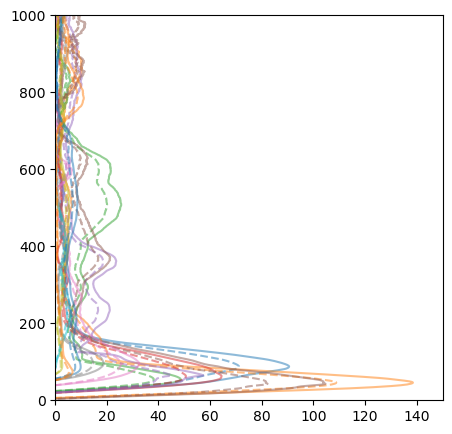

In [7]:
# calculate extinction in same way as paper does eg Figure 1 caption
ext_derived = profiles.backscatter * L

# compare measured and calculated extinction coefficients
fig = plt.figure(figsize=(5,5))
for i in range(len(profiles.time)):
    profile = profiles.isel(time=i)
    ext_profile = ext_derived.isel(time=i)
    line, = plt.plot(
        profile.extinction,
        profile.height,
        alpha=0.5
    )
    plt.plot(
        ext_profile,
        ext_profile.height,
        ls="dashed",
        color=line.get_color(),
        alpha=0.5
    )

plt.ylim(0, 1000)
plt.xlim(left=0)


# Read model output
Pre-processed using other scripts

In [8]:
apr = slice(dt.datetime(2020,4,1), dt.datetime(2020,4,30))
wrfout = xr.open_mfdataset(glob.glob("/mnt/data/model_output/ACI_OPT_2/*_mosaic.nc")).sel(Time=apr)
wrfout["rho_air"] = wrfout.wrf.density_of_dry_air[:]
wrfout["air_temperature"] = wrfout.wrf.air_temperature[:]
wrfout["altitude"] =wrfout.wrf.altitude_asl_c[:]

# average over 9 nearest grid points
wrfout_9pt = wrfout.mean(["i","j"])

# 1 nearest grid point only
wrfout_1pt = wrfout.isel(i=1, j=1)


/tmp/ipykernel_9962/1169106011.py:2: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'Time' ('Time',) The recommendation is to set join explicitly for this case.
  wrfout = xr.open_mfdataset(glob.glob("/mnt/data/model_output/ACI_OPT_2/*_mosaic.nc")).sel(Time=apr)
/tmp/ipykernel_9962/1169106011.py:2: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  wrfout = xr.open_mfdataset(glob.glob("/mnt/data/model_output/ACI_OPT_2/*_mosaic.nc

In [9]:
def interp_1d(height, var, height_new):
    return np.interp(height_new, height, var)

def interp_zdim(ds, da_height_new):
    vars_to_interp = [v for v in ds.data_vars if v not in ["altitude","PH","PHB"]]
    ds_interp = xr.Dataset()
    da_height_old = ds["altitude"].drop_attrs()
    for var in vars_to_interp:
        if "bottom_top" not in ds[var].dims:
            print(f"skipping {var} with no height coordinate")
            continue
        ds_interp[var] = xr.apply_ufunc(
            interp_1d,
            da_height_old,         # first arg: height profile
            ds[var],              # second arg: variable profile
            da_height_new,        # third arg: target heights
            input_core_dims=[["bottom_top"],["bottom_top"],["bottom_top"]],
            output_core_dims=[["bottom_top"]],
            vectorize=True,           # loop automatically over (sim, time)
            dask="parallelized",      # works with dask arrays
            keep_attrs="no_conflicts"
        )
    # add new height coordinate
    ds_interp = ds_interp.assign_coords({
        'height': (['bottom_top'], da_height_new.data)
    })
    return ds_interp

In [10]:
# interpolate in vertical onto regular height levels
wrfout_9pt = interp_zdim(wrfout_9pt, wrfout_9pt.altitude.mean("Time", keep_attrs=False))
wrfout_1pt = interp_zdim(wrfout_1pt, wrfout_1pt.altitude.mean("Time", keep_attrs=False))


skipping SWUPB with no height coordinate
skipping LWUPB with no height coordinate
skipping LWDNB with no height coordinate
skipping SWDNB with no height coordinate
skipping SWUPB with no height coordinate
skipping LWUPB with no height coordinate
skipping LWDNB with no height coordinate
skipping SWDNB with no height coordinate


In [11]:
# quick check to see if using dataset.sel() gives reasonable extraction of time coordinate

for i in range(len(profiles.time)):
    time = profiles.start_time.values[i] 
    print(time, wrfout_9pt.sel(Time=time, method="nearest").Time.values)

2020-04-07T10:30:00.000000 2020-04-07T11:00:00.000000000
2020-04-09T00:00:00.000000 2020-04-09T00:00:00.000000000
2020-04-09T22:20:00.000000 2020-04-09T22:00:00.000000000
2020-04-11T06:00:00.000000 2020-04-11T06:00:00.000000000
2020-04-11T21:00:00.000000 2020-04-11T21:00:00.000000000
2020-04-12T13:40:00.000000 2020-04-12T14:00:00.000000000
2020-04-17T04:30:00.000000 2020-04-17T05:00:00.000000000
2020-04-17T12:40:00.000000 2020-04-17T13:00:00.000000000
2020-04-22T00:00:00.000000 2020-04-22T00:00:00.000000000
2020-04-24T00:00:00.000000 2020-04-24T00:00:00.000000000
2020-04-26T00:00:00.000000 2020-04-26T00:00:00.000000000
2020-04-29T15:40:00.000000 2020-04-29T16:00:00.000000000


Text(0.5, 0, 'Extinction coefficient [Mm-1]')

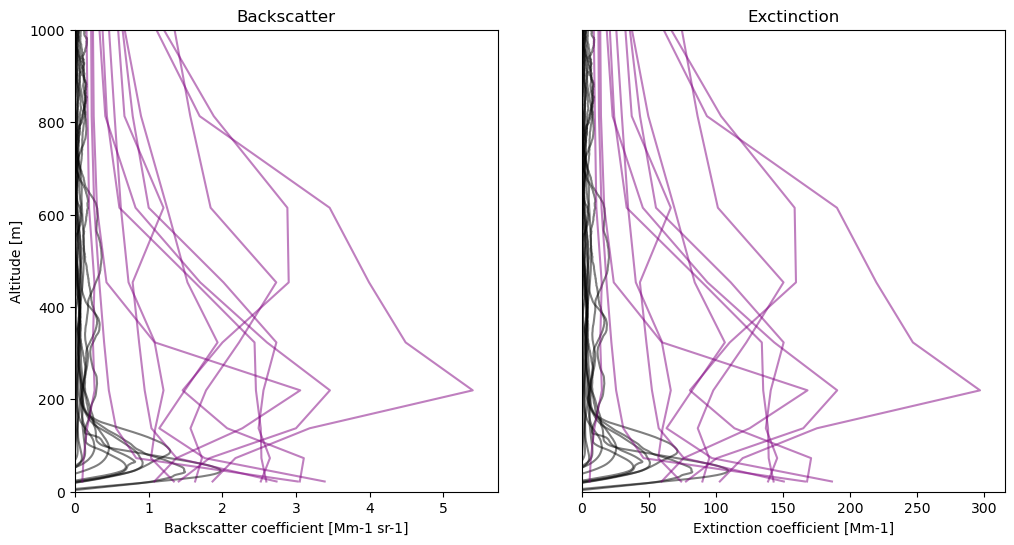

In [13]:
# plot all April lidar profiles on one figure

fig, axes = plt.subplots(1, 2, figsize=(12,6))
for i in range(len(profiles.time)):
    time = profiles.start_time.values[i]
    profile = profiles.isel(time=i)
    ext_profile = ext_derived.isel(time=i)
    model_profile = wrfout_9pt.EXTCOF55.sel(Time=time, method="nearest")
    axes[0].plot(
        profile.backscatter,
        profile.height,
        color="k",
        alpha=0.5
    )
    axes[0].plot(
        1000*model_profile/L,
        model_profile.height,
        color="purple",
        alpha=0.5
    )

    axes[1].plot(
        ext_profile,
        ext_profile.height,
        color="k",
        alpha=0.5
    )
    axes[1].plot(
        1000*model_profile,
        model_profile.height,
        color="purple",
        alpha=0.5
    )


for ax in axes:
    ax.set_ylim(0, 1000)
    ax.set_xlim(left=0)

axes[1].set_yticks([])
axes[0].set_title("Backscatter")
axes[1].set_title("Exctinction")
axes[0].set_xlabel("Backscatter coefficient [Mm-1 sr-1]")
axes[0].set_ylabel("Altitude [m]")
axes[1].set_xlabel("Extinction coefficient [Mm-1]")


Text(0.5, 0, 'Extinction coefficient [Mm-1]')

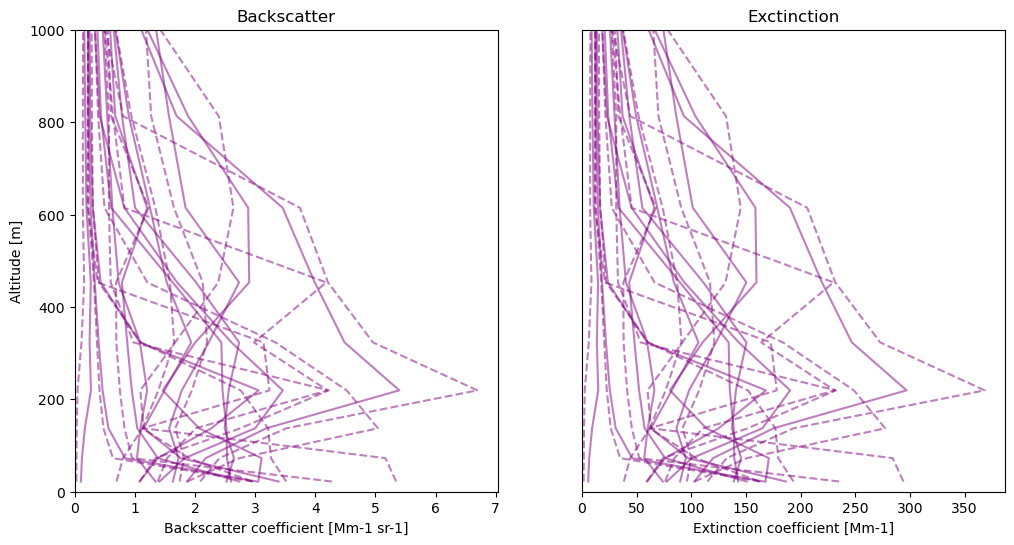

In [22]:
# compare profiles from 9 grid points vs 1 grid point
# plot all April lidar profiles on one figure

fig, axes = plt.subplots(1, 2, figsize=(12,6))
for i in range(len(profiles.time)):
    time = profiles.start_time.values[i]
    model_profile = wrfout_9pt.EXTCOF55.sel(Time=time, method="nearest")
    model_profile2 = wrfout_1pt.EXTCOF55.sel(Time=time, method="nearest")
    axes[0].plot(
        1000*model_profile/L,
        model_profile.height,
        color="purple",
        alpha=0.5
    )
    axes[0].plot(
        1000*model_profile2/L,
        model_profile2.height,
        color="purple",
        ls="dashed",
        alpha=0.5
    )

    axes[1].plot(
        1000*model_profile,
        model_profile.height,
        color="purple",
        alpha=0.5
    )
    axes[1].plot(
        1000*model_profile2,
        model_profile2.height,
        color="purple",
        ls="dashed",
        alpha=0.5
    )


for ax in axes:
    ax.set_ylim(0, 1000)
    ax.set_xlim(left=0)

axes[1].set_yticks([])
axes[0].set_title("Backscatter")
axes[1].set_title("Exctinction")
axes[0].set_xlabel("Backscatter coefficient [Mm-1 sr-1]")
axes[0].set_ylabel("Altitude [m]")
axes[1].set_xlabel("Extinction coefficient [Mm-1]")


Text(0.5, 0.95, '2020-04-17 04:30')

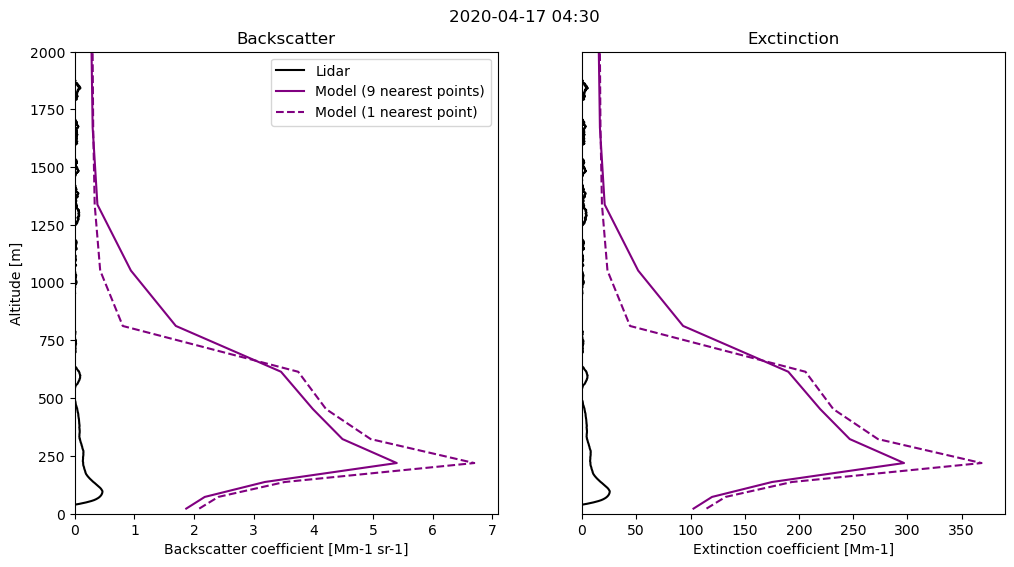

In [24]:
# plot single profile to send round as an example

i = 6

fig, axes = plt.subplots(1, 2, figsize=(12,6))
time = profiles.start_time.values[i]
profile = profiles.isel(time=i)
ext_profile = ext_derived.isel(time=i)
model_profile = wrfout_9pt.EXTCOF55.sel(Time=time, method="nearest")
model_profile2 = wrfout_1pt.EXTCOF55.sel(Time=time, method="nearest")
axes[0].plot(
    profile.backscatter,
    profile.height,
    color="k",
    label="Lidar"
)
axes[0].plot(
    1000*model_profile/L,
    model_profile.height,
    color="purple",
    label="Model (9 nearest points)"
)
axes[0].plot(
    1000*model_profile2/L,
    model_profile2.height,
    color="purple",
    ls="dashed",
    label="Model (1 nearest point)"
)
axes[1].plot(
    ext_profile,
    ext_profile.height,
    color="k",
)
axes[1].plot(
    1000*model_profile,
    model_profile.height,
    color="purple",
)
axes[1].plot(
    1000*model_profile2,
    model_profile2.height,
    color="purple",
    ls="dashed"
)

for ax in axes:
    ax.set_ylim(0, 2000)
    ax.set_xlim(left=0)

axes[0].legend()
axes[1].set_yticks([])
axes[0].set_title("Backscatter")
axes[1].set_title("Exctinction")
axes[0].set_xlabel("Backscatter coefficient [Mm-1 sr-1]")
axes[0].set_ylabel("Altitude [m]")
axes[1].set_xlabel("Extinction coefficient [Mm-1]")
fig.suptitle(dt.datetime.strftime(pd.to_datetime(time), "%Y-%m-%d %H:%M"), y=0.95)